## Import all the Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from google.colab import files

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
%matplotlib inline

COLORS = ['#2196F3', '#FF5722', '#E91E63', '#4CAF50']
CHANNELS = ['In-Store', 'Uber Eats', 'DoorDash', 'Self-Delivery']

print(' Libraries imported!')

 Libraries imported!


##  Step 2: Load & Explore Dataset

In [7]:
# Upload the CSV file
print('Upload SkyCity_Auckland_Restaurants___Bars.csv')
uploaded = files.upload()
filename = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[filename]))

# Add calculated columns
df['TotalRevenue']   = df['InStoreRevenue'] + df['UberEatsRevenue'] + df['DoorDashRevenue'] + df['SelfDeliveryRevenue']
df['TotalNetProfit'] = df['InStoreNetProfit'] + df['UberEatsNetProfit'] + df['DoorDashNetProfit'] + df['SelfDeliveryNetProfit']
df['AggregatorShare']= df['UE_share'] + df['DD_share']
df['DivScore']       = (1 - df[['InStoreShare','UE_share','DD_share','SD_share']].std(axis=1)).round(3)
df['HighRisk']       = df['AggregatorShare'] > 0.70

print(f'\n Loaded: {filename}')
print(f'Shape      : {df.shape}')
print(f'Cuisines   : {sorted(df["CuisineType"].unique().tolist())}')
print(f'Segments   : {sorted(df["Segment"].unique().tolist())}')
print(f'Subregions : {sorted(df["Subregion"].unique().tolist())}')
df.head()

Upload SkyCity_Auckland_Restaurants___Bars.csv


Saving SkyCity Auckland Restaurants & Bars.csv to SkyCity Auckland Restaurants & Bars (1).csv

 Loaded: SkyCity Auckland Restaurants & Bars (1).csv
Shape      : (1696, 35)
Cuisines   : ['Burgers', 'Chicken Dishes', 'Chinese', 'Indian', 'Japanese', 'Kebabs/Mediterranean', 'Pizza', 'Thai']
Segments   : ['Cafe', 'Full-service', 'Ghost Kitchen', 'QSR']
Subregions : ['CBD', 'North Shore', 'South Auckland', 'West Auckland']


,CuisineType,RestaurantID,RestaurantName,Segment,Subregion,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,...,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share,TotalRevenue,TotalNetProfit,AggregatorShare,DivScore,HighRisk
0,Burgers,25731,Urban Burgers House,Cafe,North Shore,1.03,43.97,668,197,8662.09,...,2177.19,0.42,0.45,0.25,0.3,29371.96,7964.56,0.7,0.905,False
1,Burgers,25123,Urban Burgers Diner,QSR,South Auckland,1.05,40.45,1388,259,10476.55,...,3119.38,0.23,0.45,0.25,0.3,56144.60,8775.70,0.7,0.901,False
2,Burgers,25177,King Burgers Eatery,Cafe,West Auckland,1.04,40.03,1717,524,20975.72,...,4172.99,0.44,0.45,0.25,0.3,68731.51,14403.26,0.7,0.900,False
3,Burgers,25540,Classic Burgers Tavern,QSR,North Shore,1.03,36.28,1083,216,7836.48,...,2833.26,0.25,0.45,0.25,0.3,39291.24,5266.83,0.7,0.905,False
4,Burgers,25258,Lucky Burgers Bistro,Cafe,South Auckland,1.05,34.34,1230,261,8962.74,...,2674.56,0.27,0.45,0.25,0.3,42238.20,6119.35,0.7,0.909,False


In [8]:
print('=== BASIC INFO ===')
df.info()
print('\n=== STATISTICAL SUMMARY ===')
df.describe().round(2)

=== BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1696 entries, 0 to 1695
Data columns (total 35 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   CuisineType            1696 non-null   object 
 1   RestaurantID           1696 non-null   int64  
 2   RestaurantName         1696 non-null   object 
 3   Segment                1696 non-null   object 
 4   Subregion              1696 non-null   object 
 5   GrowthFactor           1696 non-null   float64
 6   AOV                    1696 non-null   float64
 7   MonthlyOrders          1696 non-null   int64  
 8   InStoreOrders          1696 non-null   int64  
 9   InStoreRevenue         1696 non-null   float64
 10  UberEatsOrders         1696 non-null   int64  
 11  DoorDashOrders         1696 non-null   int64  
 12  SelfDeliveryOrders     1696 non-null   int64  
 13  UberEatsRevenue        1696 non-null   float64
 14  DoorDashRevenue        1696 non-null 

,RestaurantID,GrowthFactor,AOV,MonthlyOrders,InStoreOrders,InStoreRevenue,UberEatsOrders,DoorDashOrders,SelfDeliveryOrders,UberEatsRevenue,...,DoorDashNetProfit,SelfDeliveryNetProfit,InStoreShare,UE_share,DD_share,SD_share,TotalRevenue,TotalNetProfit,AggregatorShare,DivScore
count,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,...,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00,1696.00
mean,25848.50,1.03,38.52,1190.53,218.98,8422.39,471.91,257.16,242.49,18170.03,...,89.11,2139.32,0.23,0.49,0.27,0.25,45836.86,4638.15,0.75,0.85
std,489.74,0.02,4.46,422.33,149.76,5851.23,171.78,92.61,129.95,6959.24,...,1271.83,1875.80,0.13,0.07,0.03,0.09,17142.77,5829.60,0.09,0.04
min,25001.00,0.99,29.79,441.00,13.00,412.36,142.00,81.00,60.00,5050.95,...,-4349.94,-983.28,0.03,0.35,0.20,0.15,14106.42,-10192.83,0.55,0.76
25%,25424.75,1.03,34.79,827.00,101.00,3904.34,331.00,179.75,146.00,12524.74,...,-718.62,807.87,0.11,0.45,0.25,0.15,31539.74,556.61,0.70,0.82
50%,25848.50,1.04,38.34,1182.00,178.00,6791.43,456.00,249.00,212.00,17548.98,...,369.66,1742.95,0.21,0.50,0.25,0.20,44686.00,4932.86,0.80,0.84
75%,26272.25,1.05,42.50,1525.00,307.00,11550.76,602.00,326.25,306.25,23016.00,...,862.60,2995.28,0.32,0.55,0.30,0.30,58178.86,8419.29,0.85,0.89
max,26696.00,1.05,47.23,2337.00,819.00,35356.23,937.00,466.00,702.00,43038.96,...,4514.88,13222.10,0.55,0.60,0.30,0.45,100888.29,27368.36,0.85,0.92


##  Step 3: Data Validation

In [9]:
print('=== DATA VALIDATION ===\n')

# 1. Null check
nulls = df.isnull().sum().sum()
print(f'1. Missing values     : {nulls} ' if nulls == 0 else f'1. Missing values: {nulls} ')

# 2. Order count consistency
df['OrdersSum'] = df['InStoreOrders'] + df['UberEatsOrders'] + df['DoorDashOrders'] + df['SelfDeliveryOrders']
mismatch = (df['OrdersSum'] != df['MonthlyOrders']).sum()
print(f'2. Order count match  : {mismatch} mismatches ' if mismatch == 0 else f'2. Mismatches: {mismatch} ')

# 3. Share sum check
df['ShareSum'] = (df['InStoreShare'] + df['UE_share'] + df['DD_share'] + df['SD_share']).round(2)
share_issues = (abs(df['ShareSum'] - 1.0) > 0.05).sum()
print(f'3. Share sum ~100%    : {share_issues} issues ' if share_issues == 0 else f'3. Share issues: {share_issues} ')

# 4. Duplicate check
dups = df.duplicated().sum()
print(f'4. Duplicate rows     : {dups} ' if dups == 0 else f'4. Duplicates: {dups} ')

# 5. Outliers
q1, q3 = df['MonthlyOrders'].quantile([0.25, 0.75])
iqr = q3 - q1
outliers = ((df['MonthlyOrders'] < q1 - 1.5*iqr) | (df['MonthlyOrders'] > q3 + 1.5*iqr)).sum()
print(f'5. MonthlyOrders outliers: {outliers}')

print('\n Dataset is clean and ready for analysis!')

=== DATA VALIDATION ===

1. Missing values     : 0 
2. Order count match  : 0 mismatches 
3. Share issues: 1665 
4. Duplicate rows     : 0 
5. MonthlyOrders outliers: 0

 Dataset is clean and ready for analysis!


##  Step 4: KPI Summary

   SKYCITY AUCKLAND — KPI SUMMARY
  Total Restaurants      : 1,696
  Total Monthly Orders   : 2,019,134
  Total Revenue          : $77,739,306.80
  Total Net Profit       : $7,866,306.13
  Overall Profit Margin  : 10.1%
  Avg Order Value (AOV)  : $38.52
  High Risk Restaurants  : 1,102 (65.0%)
  Avg Diversification    : 0.851 / 1.0


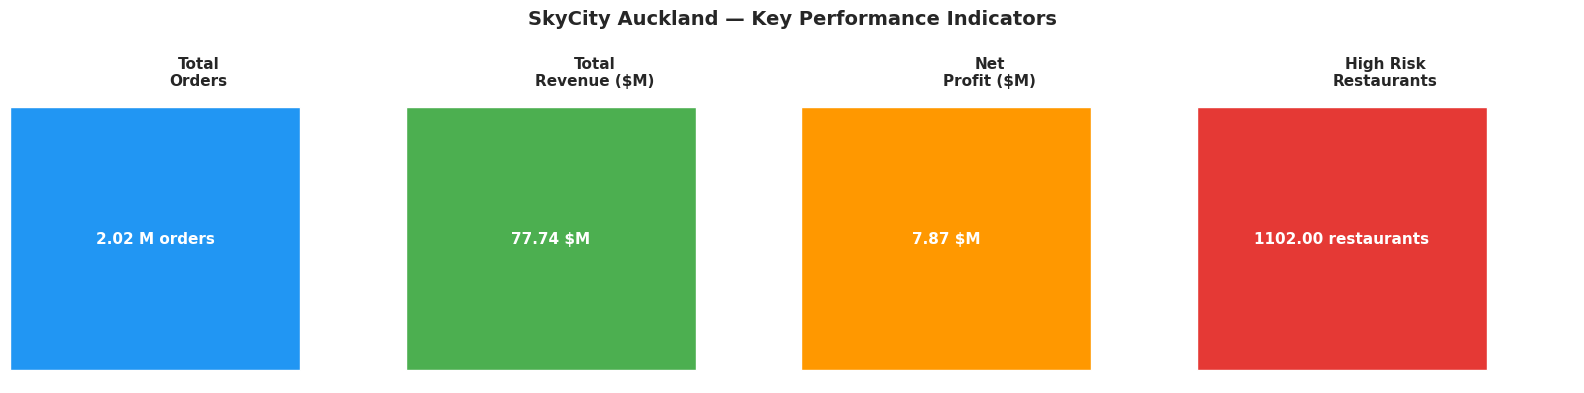

In [10]:
total_restaurants = df['RestaurantID'].nunique()
total_orders      = df['MonthlyOrders'].sum()
total_revenue     = df['TotalRevenue'].sum()
total_profit      = df['TotalNetProfit'].sum()
avg_aov           = df['AOV'].mean()
high_risk         = df['HighRisk'].sum()
avg_div           = df['DivScore'].mean()

print('=' * 50)
print('   SKYCITY AUCKLAND — KPI SUMMARY')
print('=' * 50)
print(f'  Total Restaurants      : {total_restaurants:,}')
print(f'  Total Monthly Orders   : {total_orders:,}')
print(f'  Total Revenue          : ${total_revenue:,.2f}')
print(f'  Total Net Profit       : ${total_profit:,.2f}')
print(f'  Overall Profit Margin  : {total_profit/total_revenue*100:.1f}%')
print(f'  Avg Order Value (AOV)  : ${avg_aov:.2f}')
print(f'  High Risk Restaurants  : {high_risk:,} ({high_risk/total_restaurants*100:.1f}%)')
print(f'  Avg Diversification    : {avg_div:.3f} / 1.0')
print('=' * 50)

# KPI bar chart
kpi_labels = ['Total\nOrders', 'Total\nRevenue ($M)', 'Net\nProfit ($M)', 'High Risk\nRestaurants']
kpi_vals   = [total_orders/1e6, total_revenue/1e6, total_profit/1e6, high_risk]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
kpi_colors = ['#2196F3','#4CAF50','#FF9800','#E53935']
kpi_units  = ['M orders', '$M', '$M', 'restaurants']

for ax, label, val, color, unit in zip(axes, kpi_labels, kpi_vals, kpi_colors, kpi_units):
    ax.barh([0], [val], color=color, height=0.4)
    ax.set_xlim(0, val * 1.3)
    ax.set_yticks([])
    ax.set_title(label, fontweight='bold', fontsize=11)
    ax.text(val * 0.5, 0, f'{val:.2f} {unit}', ha='center', va='center',
            color='white', fontweight='bold', fontsize=11)
    ax.set_xticks([])
    for spine in ax.spines.values(): spine.set_visible(False)

plt.suptitle('SkyCity Auckland — Key Performance Indicators', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 5: Channel Volume & Market Share

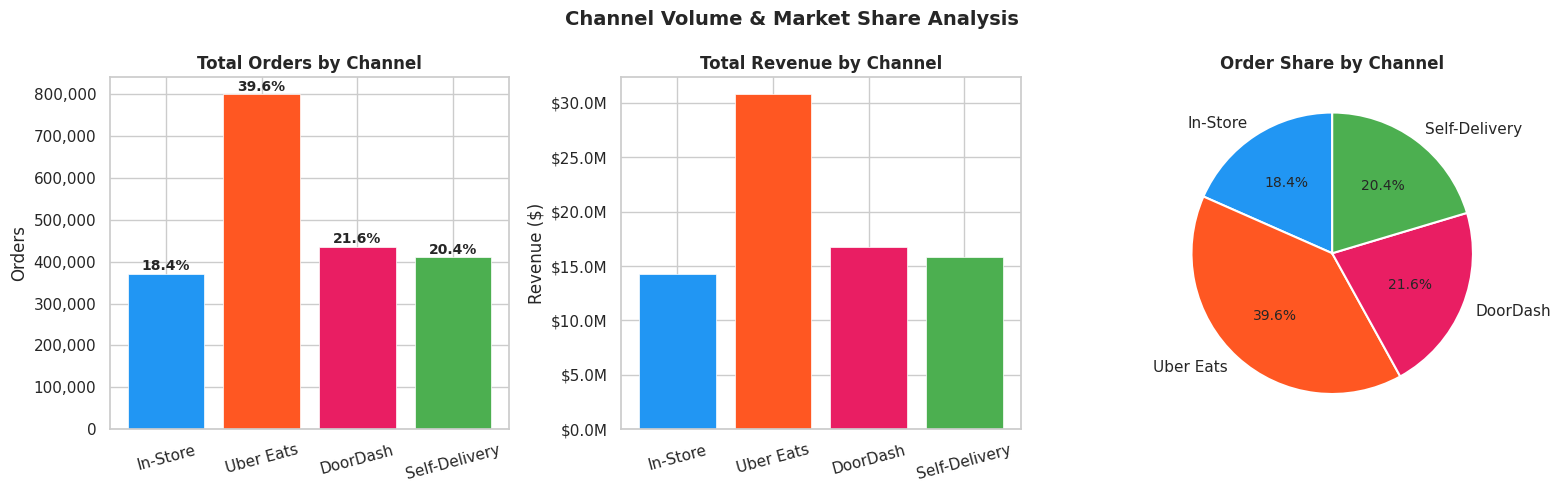


=== CHANNEL ORDER SHARE ===
  In-Store       :  371,391 orders  (18.4%)
  Uber Eats      :  800,353 orders  (39.6%)
  DoorDash       :  436,135 orders  (21.6%)
  Self-Delivery  :  411,255 orders  (20.4%)


In [11]:
orders  = [df['InStoreOrders'].sum(), df['UberEatsOrders'].sum(),
           df['DoorDashOrders'].sum(), df['SelfDeliveryOrders'].sum()]
revenue = [df['InStoreRevenue'].sum(), df['UberEatsRevenue'].sum(),
           df['DoorDashRevenue'].sum(), df['SelfDeliveryRevenue'].sum()]
profit  = [df['InStoreNetProfit'].sum(), df['UberEatsNetProfit'].sum(),
           df['DoorDashNetProfit'].sum(), df['SelfDeliveryNetProfit'].sum()]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Orders bar
bars = axes[0].bar(CHANNELS, orders, color=COLORS, edgecolor='white', linewidth=0.5)
axes[0].set_title('Total Orders by Channel', fontweight='bold')
axes[0].set_ylabel('Orders')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, orders):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+8000,
                 f'{val/sum(orders)*100:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Revenue bar
axes[1].bar(CHANNELS, revenue, color=COLORS, edgecolor='white', linewidth=0.5)
axes[1].set_title('Total Revenue by Channel', fontweight='bold')
axes[1].set_ylabel('Revenue ($)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].tick_params(axis='x', rotation=15)

# Donut chart
wedges, texts, autotexts = axes[2].pie(
    orders, labels=CHANNELS, autopct='%1.1f%%',
    colors=COLORS, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':1.5}
)
axes[2].set_title('Order Share by Channel', fontweight='bold')
for text in autotexts: text.set_fontsize(10)

plt.suptitle('Channel Volume & Market Share Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== CHANNEL ORDER SHARE ===')
for ch, o in zip(CHANNELS, orders):
    print(f'  {ch:<15}: {o:>8,} orders  ({o/sum(orders)*100:.1f}%)')

##  Step 6: Geographic Channel Analysis

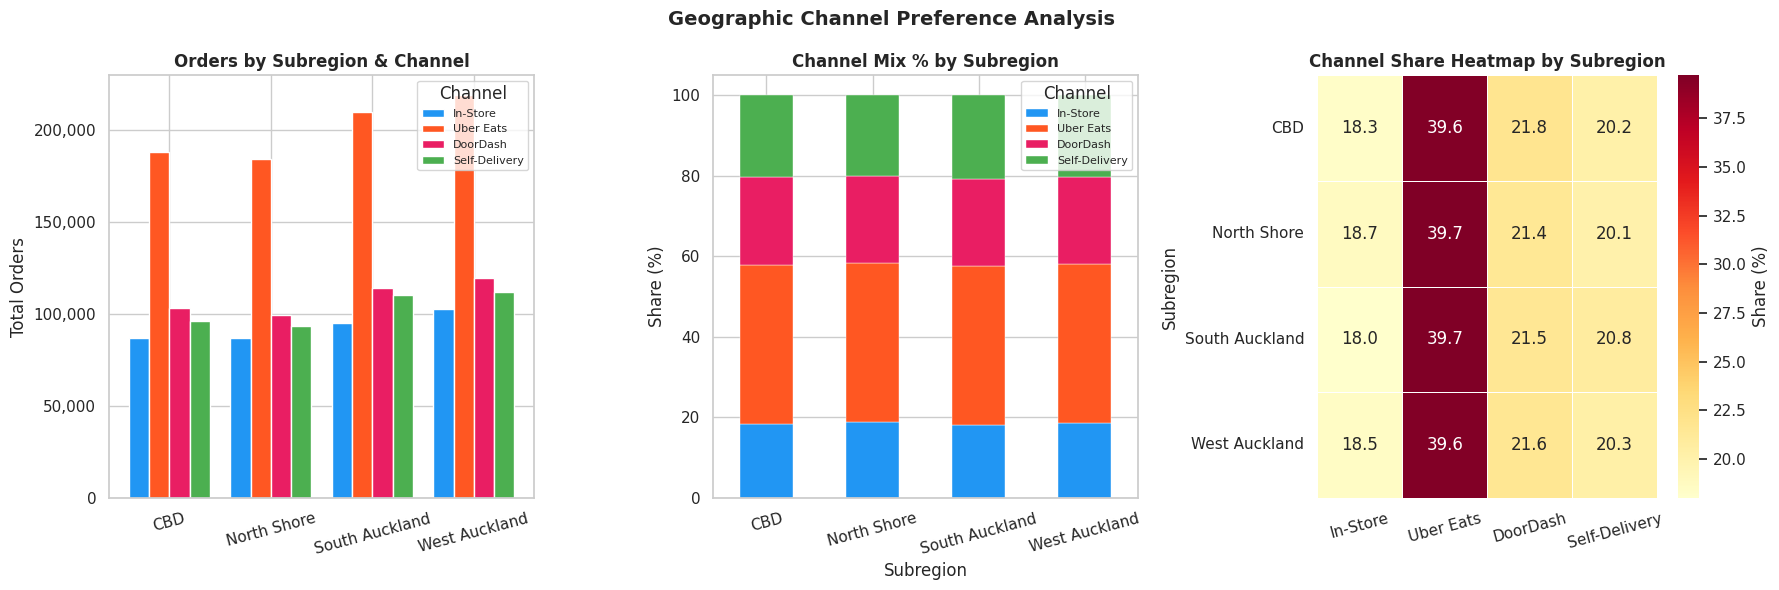


=== DOMINANT CHANNEL BY SUBREGION ===
  CBD                → Uber Eats (187,736 orders)
  North Shore        → Uber Eats (183,977 orders)
  South Auckland     → Uber Eats (209,895 orders)
  West Auckland      → Uber Eats (218,745 orders)


In [13]:
sub_orders = df.groupby('Subregion')[
    ['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']
].sum().reset_index()
sub_orders.columns = ['Subregion'] + CHANNELS

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grouped bar
x = range(len(sub_orders))
width = 0.2
for i, (ch, color) in enumerate(zip(CHANNELS, COLORS)):
    axes[0].bar([j + i*width for j in x], sub_orders[ch],
                width, label=ch, color=color, edgecolor='white')
axes[0].set_xticks([j + 1.5*width for j in x])
axes[0].set_xticklabels(sub_orders['Subregion'], rotation=15)
axes[0].set_title('Orders by Subregion & Channel', fontweight='bold')
axes[0].set_ylabel('Total Orders')
axes[0].legend(title='Channel', fontsize=8)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))

# Stacked % bar
sub_pct = sub_orders.set_index('Subregion')[CHANNELS]
sub_pct = sub_pct.div(sub_pct.sum(axis=1), axis=0) * 100
sub_pct.plot(kind='bar', stacked=True, ax=axes[1],
             color=COLORS, edgecolor='white', linewidth=0.3)
axes[1].set_title('Channel Mix % by Subregion', fontweight='bold')
axes[1].set_ylabel('Share (%)')
axes[1].tick_params(axis='x', rotation=15)
axes[1].legend(title='Channel', fontsize=8)

# Heatmap
sns.heatmap(sub_pct.round(1), annot=True, fmt='.1f',
            cmap='YlOrRd', ax=axes[2], linewidths=0.5,
            cbar_kws={'label':'Share (%)'})
axes[2].set_title('Channel Share Heatmap by Subregion', fontweight='bold')
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=15)
axes[2].set_yticklabels(axes[2].get_yticklabels(), rotation=0)

plt.suptitle('Geographic Channel Preference Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== DOMINANT CHANNEL BY SUBREGION ===')
for _, row in sub_orders.iterrows():
    vals = row[CHANNELS]
    print(f'  {row["Subregion"]:<18} → {vals.idxmax()} ({vals.max():,} orders)')

##  Step 7: Cuisine Channel Analysis

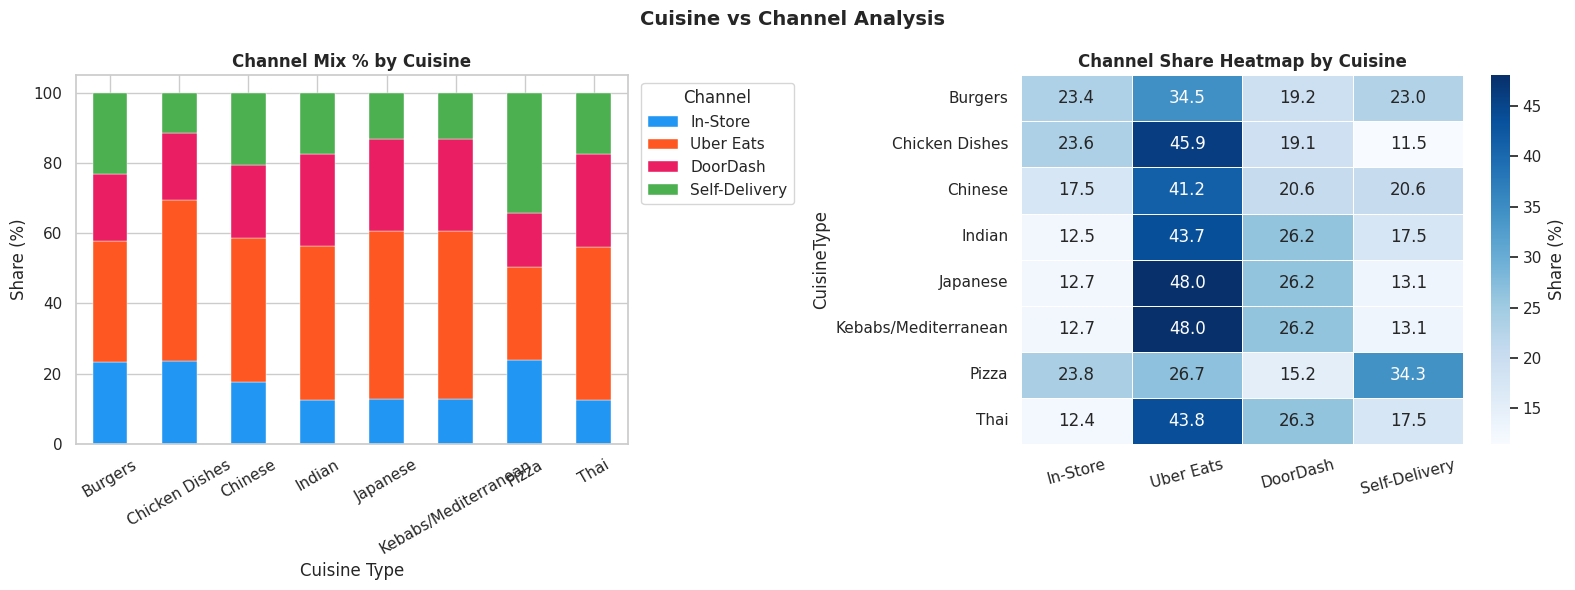


=== DOMINANT CHANNEL BY CUISINE ===
  Burgers                   → Uber Eats (34.5%)
  Chicken Dishes            → Uber Eats (45.9%)
  Chinese                   → Uber Eats (41.2%)
  Indian                    → Uber Eats (43.7%)
  Japanese                  → Uber Eats (48.0%)
  Kebabs/Mediterranean      → Uber Eats (48.0%)
  Pizza                     → Self-Delivery (34.3%)
  Thai                      → Uber Eats (43.8%)


In [14]:
cui_orders = df.groupby('CuisineType')[
    ['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']
].sum()
cui_orders.columns = CHANNELS
cui_pct = cui_orders.div(cui_orders.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Stacked bar
cui_pct.plot(kind='bar', stacked=True, ax=axes[0],
             color=COLORS, edgecolor='white', linewidth=0.3)
axes[0].set_title('Channel Mix % by Cuisine', fontweight='bold')
axes[0].set_xlabel('Cuisine Type')
axes[0].set_ylabel('Share (%)')
axes[0].tick_params(axis='x', rotation=30)
axes[0].legend(title='Channel', bbox_to_anchor=(1.01, 1))

# Heatmap
sns.heatmap(cui_pct.round(1), annot=True, fmt='.1f',
            cmap='Blues', ax=axes[1], linewidths=0.5,
            cbar_kws={'label':'Share (%)'})
axes[1].set_title('Channel Share Heatmap by Cuisine', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Cuisine vs Channel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== DOMINANT CHANNEL BY CUISINE ===')
for cuisine in cui_pct.index:
    dom = cui_pct.loc[cuisine].idxmax()
    val = cui_pct.loc[cuisine].max()
    print(f'  {cuisine:<25} → {dom} ({val:.1f}%)')

##  Step 8: Segment Channel Analysis

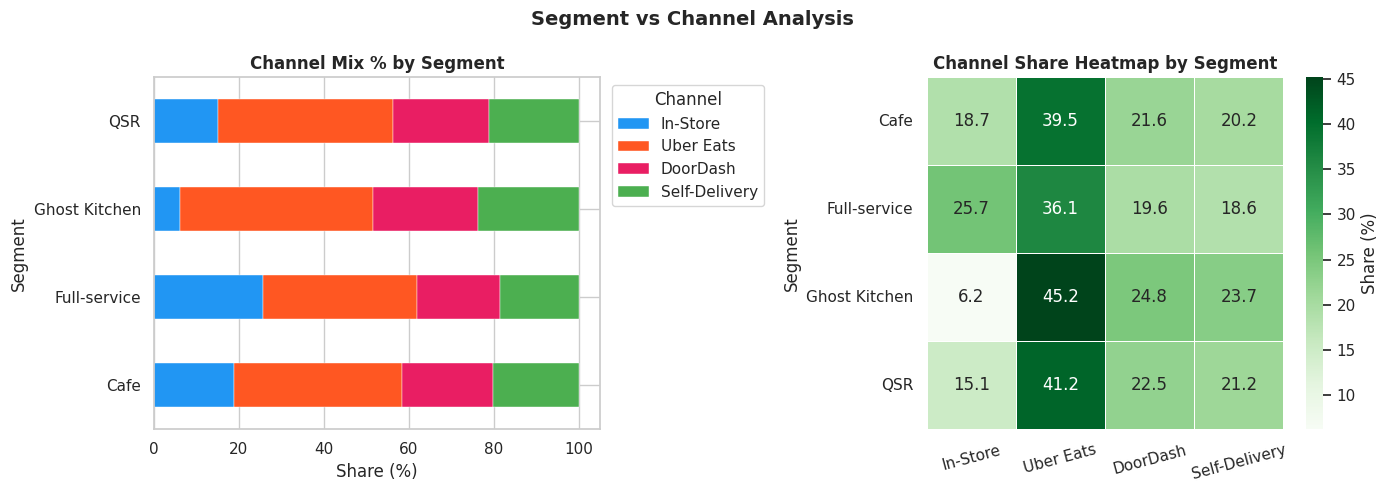


=== DOMINANT CHANNEL BY SEGMENT ===
  Cafe            → Uber Eats (39.5%)
  Full-service    → Uber Eats (36.1%)
  Ghost Kitchen   → Uber Eats (45.2%)
  QSR             → Uber Eats (41.2%)


In [15]:
seg_orders = df.groupby('Segment')[
    ['InStoreOrders','UberEatsOrders','DoorDashOrders','SelfDeliveryOrders']
].sum()
seg_orders.columns = CHANNELS
seg_pct = seg_orders.div(seg_orders.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_pct.plot(kind='barh', stacked=True, ax=axes[0],
             color=COLORS, edgecolor='white', linewidth=0.3)
axes[0].set_title('Channel Mix % by Segment', fontweight='bold')
axes[0].set_xlabel('Share (%)')
axes[0].legend(title='Channel', bbox_to_anchor=(1.01, 1))

sns.heatmap(seg_pct.round(1), annot=True, fmt='.1f',
            cmap='Greens', ax=axes[1], linewidths=0.5,
            cbar_kws={'label':'Share (%)'})
axes[1].set_title('Channel Share Heatmap by Segment', fontweight='bold')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=15)
axes[1].set_yticklabels(axes[1].get_yticklabels(), rotation=0)

plt.suptitle('Segment vs Channel Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n=== DOMINANT CHANNEL BY SEGMENT ===')
for seg in seg_pct.index:
    dom = seg_pct.loc[seg].idxmax()
    val = seg_pct.loc[seg].max()
    print(f'  {seg:<15} → {dom} ({val:.1f}%)')

## Step 9: Channel Dependency Risk Analysis

High Risk Restaurants (>70% aggregator): 1,102 / 1,696 (65.0%)



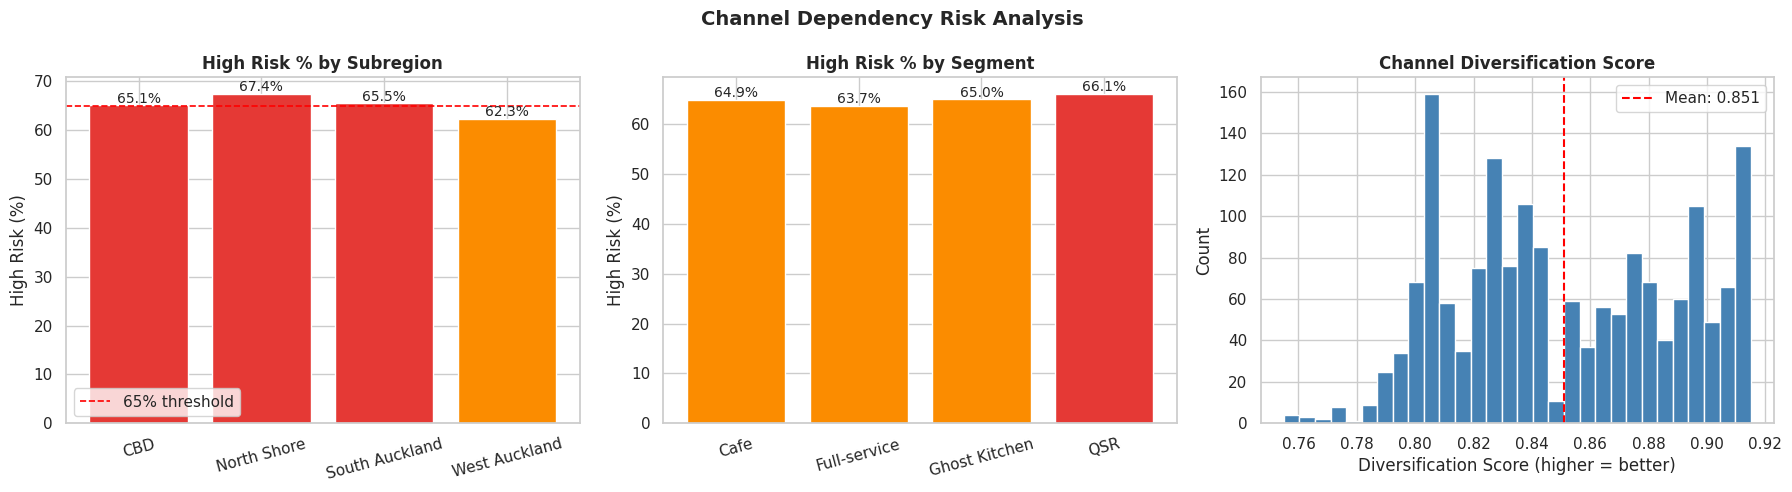

Risk by Subregion:
     Subregion  Total  HighRisk  RiskPct
           CBD    410       267     65.1
   North Shore    383       258     67.4
South Auckland    441       289     65.5
 West Auckland    462       288     62.3

Risk by Segment:
      Segment  Total  HighRisk  RiskPct
         Cafe    504       327     64.9
 Full-service    452       288     63.7
Ghost Kitchen    197       128     65.0
          QSR    543       359     66.1


In [16]:
print(f'High Risk Restaurants (>70% aggregator): {df["HighRisk"].sum():,} / {len(df):,} ({df["HighRisk"].mean()*100:.1f}%)\n')

risk_sub = df.groupby('Subregion').agg(
    Total=('RestaurantID','count'), HighRisk=('HighRisk','sum')
).reset_index()
risk_sub['RiskPct'] = (risk_sub['HighRisk'] / risk_sub['Total'] * 100).round(1)

risk_seg = df.groupby('Segment').agg(
    Total=('RestaurantID','count'), HighRisk=('HighRisk','sum')
).reset_index()
risk_seg['RiskPct'] = (risk_seg['HighRisk'] / risk_seg['Total'] * 100).round(1)

risk_cui = df.groupby('CuisineType').agg(
    Total=('RestaurantID','count'), HighRisk=('HighRisk','sum')
).reset_index()
risk_cui['RiskPct'] = (risk_cui['HighRisk'] / risk_cui['Total'] * 100).round(1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def risk_color(v):
    return '#E53935' if v > 65 else '#FB8C00' if v > 50 else '#43A047'

# By subregion
colors_sub = [risk_color(v) for v in risk_sub['RiskPct']]
bars = axes[0].bar(risk_sub['Subregion'], risk_sub['RiskPct'], color=colors_sub, edgecolor='white')
axes[0].axhline(65, color='red', linestyle='--', lw=1.2, label='65% threshold')
axes[0].set_title('High Risk % by Subregion', fontweight='bold')
axes[0].set_ylabel('High Risk (%)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].legend()
for bar, val in zip(bars, risk_sub['RiskPct']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val}%', ha='center', fontsize=10)

# By segment
colors_seg = [risk_color(v) for v in risk_seg['RiskPct']]
bars2 = axes[1].bar(risk_seg['Segment'], risk_seg['RiskPct'], color=colors_seg, edgecolor='white')
axes[1].set_title('High Risk % by Segment', fontweight='bold')
axes[1].set_ylabel('High Risk (%)')
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, risk_seg['RiskPct']):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 f'{val}%', ha='center', fontsize=10)

# Diversification score distribution
axes[2].hist(df['DivScore'], bins=30, color='steelblue', edgecolor='white')
axes[2].axvline(df['DivScore'].mean(), color='red', linestyle='--',
                label=f'Mean: {df["DivScore"].mean():.3f}')
axes[2].set_title('Channel Diversification Score', fontweight='bold')
axes[2].set_xlabel('Diversification Score (higher = better)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.suptitle('Channel Dependency Risk Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Risk by Subregion:')
print(risk_sub[['Subregion','Total','HighRisk','RiskPct']].to_string(index=False))
print('\nRisk by Segment:')
print(risk_seg[['Segment','Total','HighRisk','RiskPct']].to_string(index=False))

In [17]:
# Top 20 highest risk restaurants
print('=== TOP 20 HIGHEST RISK RESTAURANTS ===')
risk_table = df[df['HighRisk']][
    ['RestaurantName','CuisineType','Segment','Subregion','AggregatorShare','DivScore','MonthlyOrders']
].sort_values('AggregatorShare', ascending=False).head(20)
risk_table['AggregatorShare%'] = (risk_table['AggregatorShare']*100).round(1)
print(risk_table[['RestaurantName','CuisineType','Segment','Subregion','AggregatorShare%','DivScore']].to_string(index=False))

=== TOP 20 HIGHEST RISK RESTAURANTS ===
RestaurantName CuisineType       Segment      Subregion  AggregatorShare%  DivScore
    Red Bistro    Japanese          Cafe    North Shore              85.0     0.822
  Lotus Bistro    Japanese  Full-service            CBD              85.0     0.832
  Dragon Grill    Japanese  Full-service  West Auckland              85.0     0.814
   Sakura Cafe    Japanese  Full-service  West Auckland              85.0     0.811
     Red Grill    Japanese          Cafe    North Shore              85.0     0.818
  Lotus Bistro    Japanese           QSR South Auckland              85.0     0.795
   Sakura Cafe    Japanese          Cafe            CBD              85.0     0.820
   Lotus Diner    Japanese Ghost Kitchen  West Auckland              85.0     0.783
  Lotus Tavern    Japanese  Full-service South Auckland              85.0     0.816
 Dragon Eatery    Japanese  Full-service South Auckland              85.0     0.833
 Golden Bistro    Japanese  Full-ser

##  Step 10: Profitability Analysis

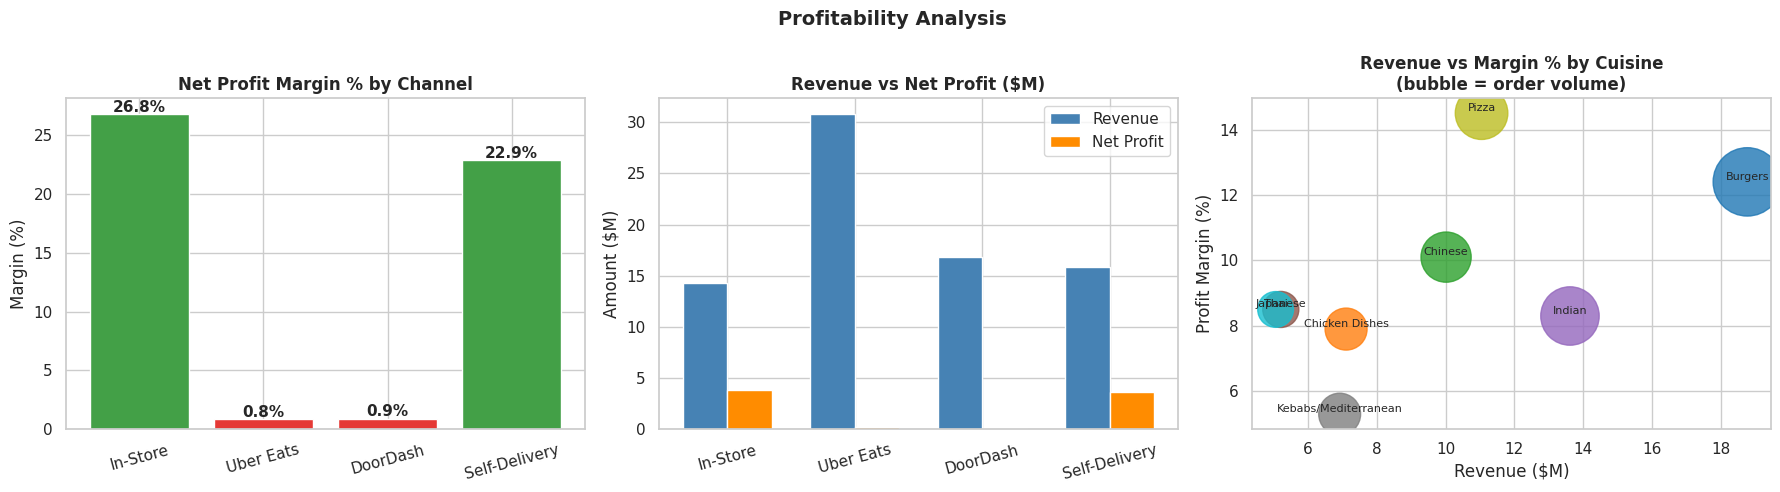


Channel Profitability Summary:
      Channel     Revenue  NetProfit  Margin%
     In-Store 14284378.07 3828417.36    26.80
    Uber Eats 30816371.49  258488.08     0.84
     DoorDash 16789380.95  151122.25     0.90
Self-Delivery 15849176.29 3628278.44    22.89


In [18]:
profit_df = pd.DataFrame({
    'Channel': CHANNELS,
    'Revenue': [df['InStoreRevenue'].sum(), df['UberEatsRevenue'].sum(),
                df['DoorDashRevenue'].sum(), df['SelfDeliveryRevenue'].sum()],
    'NetProfit': [df['InStoreNetProfit'].sum(), df['UberEatsNetProfit'].sum(),
                  df['DoorDashNetProfit'].sum(), df['SelfDeliveryNetProfit'].sum()]
})
profit_df['Margin%'] = (profit_df['NetProfit'] / profit_df['Revenue'] * 100).round(2)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Margin % by channel
margin_colors = ['#43A047' if m > 15 else '#FB8C00' if m > 5 else '#E53935'
                 for m in profit_df['Margin%']]
bars = axes[0].bar(profit_df['Channel'], profit_df['Margin%'],
                   color=margin_colors, edgecolor='white')
axes[0].set_title('Net Profit Margin % by Channel', fontweight='bold')
axes[0].set_ylabel('Margin (%)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, profit_df['Margin%']):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Revenue vs Profit grouped bar
x = range(len(CHANNELS))
w = 0.35
axes[1].bar([i-w/2 for i in x], profit_df['Revenue']/1e6, w,
            label='Revenue', color='steelblue', edgecolor='white')
axes[1].bar([i+w/2 for i in x], profit_df['NetProfit']/1e6, w,
            label='Net Profit', color='darkorange', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(CHANNELS, rotation=15)
axes[1].set_title('Revenue vs Net Profit ($M)', fontweight='bold')
axes[1].set_ylabel('Amount ($M)')
axes[1].legend()

# Cuisine profitability
cui_perf = df.groupby('CuisineType').agg(
    Revenue=('TotalRevenue','sum'),
    Profit=('TotalNetProfit','sum'),
    Orders=('MonthlyOrders','sum')
).reset_index()
cui_perf['Margin%'] = (cui_perf['Profit']/cui_perf['Revenue']*100).round(1)

axes[2].scatter(cui_perf['Revenue']/1e6, cui_perf['Margin%'],
                s=cui_perf['Orders']/200, alpha=0.8,
                c=range(len(cui_perf)), cmap='tab10')
for _, row in cui_perf.iterrows():
    axes[2].annotate(row['CuisineType'],
                     (row['Revenue']/1e6, row['Margin%']),
                     fontsize=8, ha='center', va='bottom')
axes[2].set_title('Revenue vs Margin % by Cuisine\n(bubble = order volume)', fontweight='bold')
axes[2].set_xlabel('Revenue ($M)')
axes[2].set_ylabel('Profit Margin (%)')

plt.suptitle('Profitability Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nChannel Profitability Summary:')
print(profit_df.to_string(index=False))

##  Step 11: Insights & Recommendations

In [20]:
from IPython.display import HTML

html = """
<!DOCTYPE html>
<html>
<head>
<meta charset='utf-8'>
<script src='https://cdnjs.cloudflare.com/ajax/libs/Chart.js/4.4.1/chart.umd.js'></script>
<style>
  * { box-sizing: border-box; margin: 0; padding: 0; }
  body { font-family: system-ui, sans-serif; background: #0d0d0d; color: #e0e0e0; padding: 18px; }
  .hdr { display: flex; align-items: baseline; justify-content: space-between; margin-bottom: 16px; }
  .title { font-size: 22px; font-weight: 500; }
  .accent { color: #E91E63; }
  .sub { font-size: 12px; color: #666; }
  .badge { font-size: 11px; padding: 3px 10px; border-radius: 20px; background: #2a1a0e; color: #FF9800; }
  .kgrid { display: grid; grid-template-columns: repeat(6, 1fr); gap: 10px; margin-bottom: 14px; }
  .kcard { background: #1a1a1a; border: 0.5px solid #2a2a2a; border-radius: 10px; padding: 13px 14px; }
  .kv { font-size: 20px; font-weight: 500; display: block; line-height: 1.2; }
  .kl { font-size: 11px; color: #777; display: block; margin-top: 3px; }
  .card { background: #1a1a1a; border: 0.5px solid #2a2a2a; border-radius: 10px; padding: 15px; margin-bottom: 12px; }
  .ct { font-size: 10px; font-weight: 600; color: #555; text-transform: uppercase; letter-spacing: .6px; margin-bottom: 10px; }
  .r2 { display: grid; grid-template-columns: 1fr 2fr; gap: 12px; margin-bottom: 12px; }
  .r2b { display: grid; grid-template-columns: 2fr 1fr; gap: 12px; margin-bottom: 12px; }
  .req { display: grid; grid-template-columns: 1fr 1fr; gap: 12px; margin-bottom: 12px; }
  .leg { display: flex; gap: 12px; flex-wrap: wrap; margin-bottom: 8px; font-size: 11px; color: #666; }
  .sw { width: 10px; height: 10px; border-radius: 2px; display: inline-block; margin-right: 4px; }
  .ins { border-left: 2px solid #FF9800; padding: 6px 0 6px 12px; margin-bottom: 10px; }
  .ins-t { font-size: 13px; font-weight: 500; }
  .ins-s { font-size: 11px; color: #666; margin-top: 2px; }
  .risk-grid { display: grid; grid-template-columns: repeat(4,1fr); gap: 10px; margin-top: 4px; }
  .risk-box { background: #141414; border-radius: 8px; padding: 12px; }
  .risk-label { font-size: 11px; color: #555; margin-bottom: 8px; font-weight: 600; }
  .risk-count { font-size: 18px; font-weight: 500; }
  .rpill { font-size: 11px; padding: 2px 8px; border-radius: 10px; font-weight: 500; margin-left: 6px; }
  .red { background: #2a0a0a; color: #E53935; }
  .amber { background: #2a1a00; color: #FB8C00; }
</style>
</head>
<body>

<div class='hdr'>
  <div>
    <div class='title'><span class='accent'>SkyCity Auckland</span> — Order Channel Analytics</div>
    <div class='sub' style='margin-top:4px;'>Restaurants & Bars · Channel Performance & Market Share</div>
  </div>
  <span class='badge'>1,696 restaurants · 4 channels · 4 subregions</span>
</div>

<!-- KPIs -->
<div class='kgrid'>
  <div class='kcard'><span class='kv' style='color:#2196F3;'>2.02M</span><span class='kl'>Monthly orders</span></div>
  <div class='kcard'><span class='kv' style='color:#4CAF50;'>$77.7M</span><span class='kl'>Total revenue</span></div>
  <div class='kcard'><span class='kv' style='color:#FF9800;'>$7.87M</span><span class='kl'>Net profit</span></div>
  <div class='kcard'><span class='kv' style='color:#9C27B0;'>$38.52</span><span class='kl'>Avg order value</span></div>
  <div class='kcard'><span class='kv' style='color:#E53935;'>1,102</span><span class='kl'>High risk (65%)</span></div>
  <div class='kcard'><span class='kv' style='color:#00BCD4;'>0.851</span><span class='kl'>Avg div. score</span></div>
</div>

<!-- Row 1: Volume bar full width -->
<div class='card'>
  <div class='ct'>Total orders & revenue by channel</div>
  <div class='leg'>
    <span><span class='sw' style='background:#2196F3;'></span>In-Store</span>
    <span><span class='sw' style='background:#FF5722;'></span>Uber Eats</span>
    <span><span class='sw' style='background:#E91E63;'></span>DoorDash</span>
    <span><span class='sw' style='background:#4CAF50;'></span>Self-Delivery</span>
  </div>
  <div style='display:grid;grid-template-columns:1fr 1fr;gap:12px;'>
    <div style='position:relative;height:200px;'><canvas id='c1'></canvas></div>
    <div style='position:relative;height:200px;'><canvas id='c2'></canvas></div>
  </div>
</div>

<!-- Row 2: Donut + Margin -->
<div class='r2'>
  <div class='card'>
    <div class='ct'>Order share by channel</div>
    <div style='position:relative;height:220px;'><canvas id='c3'></canvas></div>
  </div>
  <div class='card'>
    <div class='ct'>Net profit margin % by channel</div>
    <div style='position:relative;height:220px;'><canvas id='c4'></canvas></div>
  </div>
</div>

<!-- Row 3: Subregion stacked full width -->
<div class='card'>
  <div class='ct'>Channel mix by subregion (%)</div>
  <div class='leg'>
    <span><span class='sw' style='background:#2196F3;'></span>In-Store</span>
    <span><span class='sw' style='background:#FF5722;'></span>Uber Eats</span>
    <span><span class='sw' style='background:#E91E63;'></span>DoorDash</span>
    <span><span class='sw' style='background:#4CAF50;'></span>Self-Delivery</span>
  </div>
  <div style='position:relative;height:230px;'><canvas id='c5'></canvas></div>
</div>

<!-- Row 4: Cuisine + Segment -->
<div class='req'>
  <div class='card'>
    <div class='ct'>Channel mix by cuisine (%)</div>
    <div style='position:relative;height:300px;'><canvas id='c6'></canvas></div>
  </div>
  <div class='card'>
    <div class='ct'>Channel mix by segment (%)</div>
    <div style='position:relative;height:200px;'><canvas id='c7'></canvas></div>
    <div class='ct' style='margin-top:16px;'>Aggregator dependency risk by subregion</div>
    <div style='position:relative;height:140px;'><canvas id='c8'></canvas></div>
  </div>
</div>

<!-- Row 5: Revenue vs profit + Insights -->
<div class='r2b'>
  <div class='card'>
    <div class='ct'>Revenue vs net profit by channel ($M)</div>
    <div style='position:relative;height:220px;'><canvas id='c9'></canvas></div>
  </div>
  <div class='card'>
    <div class='ct'>Key insights</div>
    <div class='ins'><div class='ins-t'>Uber Eats dominates but barely profits</div><div class='ins-s'>39.6% of all orders — only 0.84% profit margin</div></div>
    <div class='ins'><div class='ins-t'>In-Store is the most profitable channel</div><div class='ins-s'>Just 18.4% of orders but 26.8% profit margin</div></div>
    <div class='ins'><div class='ins-t'>65% of restaurants are high risk</div><div class='ins-s'>1,102 restaurants over 70% aggregator reliance</div></div>
    <div class='ins'><div class='ins-t'>Ghost Kitchen most vulnerable segment</div><div class='ins-s'>Only 6.2% in-store — highest aggregator dependency</div></div>
    <div class='ins'><div class='ins-t'>Self-Delivery is underutilised</div><div class='ins-s'>22.9% margin, no commission — best alternative</div></div>
  </div>
</div>

<!-- Row 6: Risk panel -->
<div class='card'>
  <div class='ct'>Channel dependency risk by subregion</div>
  <div class='risk-grid'>
    <div class='risk-box'>
      <div class='risk-label'>CBD</div>
      <div class='risk-count'>267 <span class='rpill red'>65.1%</span></div>
      <div style='font-size:11px;color:#555;margin-top:6px;'>High-risk restaurants</div>
    </div>
    <div class='risk-box'>
      <div class='risk-label'>North Shore</div>
      <div class='risk-count'>258 <span class='rpill red'>67.4%</span></div>
      <div style='font-size:11px;color:#555;margin-top:6px;'>Highest risk subregion</div>
    </div>
    <div class='risk-box'>
      <div class='risk-label'>South Auckland</div>
      <div class='risk-count'>289 <span class='rpill red'>65.5%</span></div>
      <div style='font-size:11px;color:#555;margin-top:6px;'>High-risk restaurants</div>
    </div>
    <div class='risk-box'>
      <div class='risk-label'>West Auckland</div>
      <div class='risk-count'>288 <span class='rpill amber'>62.3%</span></div>
      <div style='font-size:11px;color:#555;margin-top:6px;'>Lowest risk subregion</div>
    </div>
  </div>
</div>

<script>
Chart.defaults.color = '#666';
Chart.defaults.font.size = 11;
Chart.defaults.plugins.legend.display = false;
const gc = 'rgba(255,255,255,0.06)';
const IS='#2196F3', UE='#FF5722', DD='#E91E63', SD='#4CAF50';
const COLS = [IS, UE, DD, SD];
const base = { responsive: true, maintainAspectRatio: false };

// C1 - Orders bar
new Chart(document.getElementById('c1'), {
  type: 'bar',
  data: {
    labels: ['In-Store','Uber Eats','DoorDash','Self-Delivery'],
    datasets: [{ data: [371391,800353,436135,411255], backgroundColor: COLS, borderRadius: 4, borderSkipped: false }]
  },
  options: { ...base, scales: {
    x: { grid: { color: gc } },
    y: { grid: { color: gc }, ticks: { callback: v => v >= 1e6 ? (v/1e6).toFixed(1)+'M' : v >= 1000 ? (v/1000).toFixed(0)+'k' : v } }
  }, plugins: { tooltip: { callbacks: { label: c => ` ${c.raw.toLocaleString()} orders` } } } }
});

// C2 - Revenue bar
new Chart(document.getElementById('c2'), {
  type: 'bar',
  data: {
    labels: ['In-Store','Uber Eats','DoorDash','Self-Delivery'],
    datasets: [{ data: [14.28,30.82,16.79,15.85], backgroundColor: COLS, borderRadius: 4, borderSkipped: false }]
  },
  options: { ...base, scales: {
    x: { grid: { color: gc } },
    y: { grid: { color: gc }, ticks: { callback: v => '$'+v+'M' } }
  }, plugins: { tooltip: { callbacks: { label: c => ` $${c.raw}M revenue` } } } }
});

// C3 - Donut
new Chart(document.getElementById('c3'), {
  type: 'doughnut',
  data: {
    labels: ['In-Store','Uber Eats','DoorDash','Self-Delivery'],
    datasets: [{ data: [371391,800353,436135,411255], backgroundColor: COLS, borderWidth: 0, hoverOffset: 6 }]
  },
  options: { ...base, cutout: '62%',
    plugins: { tooltip: { callbacks: { label: c => ` ${c.label}: ${(c.raw/2019134*100).toFixed(1)}%` } } }
  }
});

// C4 - Margin
new Chart(document.getElementById('c4'), {
  type: 'bar',
  data: {
    labels: ['In-Store','Uber Eats','DoorDash','Self-Delivery'],
    datasets: [{ data: [26.8, 0.84, 0.9, 22.89],
      backgroundColor: ['#4CAF50','#E53935','#E53935','#4CAF50'],
      borderRadius: 4, borderSkipped: false }]
  },
  options: { ...base, scales: {
    x: { grid: { color: gc } },
    y: { grid: { color: gc }, ticks: { callback: v => v+'%' } }
  }, plugins: { tooltip: { callbacks: { label: c => ` ${c.raw}% margin` } } } }
});

// C5 - Subregion stacked
new Chart(document.getElementById('c5'), {
  type: 'bar',
  data: {
    labels: ['CBD','North Shore','South Auckland','West Auckland'],
    datasets: [
      { label:'In-Store',      data:[18.3,18.7,18.0,18.5], backgroundColor:IS, borderRadius:2 },
      { label:'Uber Eats',     data:[39.6,39.7,39.7,39.6], backgroundColor:UE, borderRadius:2 },
      { label:'DoorDash',      data:[21.8,21.4,21.5,21.6], backgroundColor:DD, borderRadius:2 },
      { label:'Self-Delivery', data:[20.2,20.1,20.8,20.3], backgroundColor:SD, borderRadius:2 }
    ]
  },
  options: { ...base, scales: {
    x: { stacked: true, grid: { color: gc } },
    y: { stacked: true, max: 100, grid: { color: gc }, ticks: { callback: v => v+'%' } }
  }, plugins: { tooltip: { mode: 'index', callbacks: { label: c => ` ${c.dataset.label}: ${c.raw}%` } } } }
});

// C6 - Cuisine horizontal stacked
new Chart(document.getElementById('c6'), {
  type: 'bar',
  data: {
    labels: ['Burgers','Chicken','Chinese','Indian','Japanese','Kebabs','Pizza','Thai'],
    datasets: [
      { label:'In-Store',      data:[23.4,23.6,17.5,12.5,12.7,12.7,23.8,12.4], backgroundColor:IS, borderRadius:2 },
      { label:'Uber Eats',     data:[34.5,45.9,41.2,43.7,48.0,48.0,26.7,43.8], backgroundColor:UE, borderRadius:2 },
      { label:'DoorDash',      data:[19.2,19.1,20.6,26.2,26.2,26.2,15.2,26.3], backgroundColor:DD, borderRadius:2 },
      { label:'Self-Delivery', data:[23.0,11.5,20.6,17.5,13.1,13.1,34.3,17.5], backgroundColor:SD, borderRadius:2 }
    ]
  },
  options: { ...base, indexAxis: 'y', scales: {
    x: { stacked: true, max: 100, grid: { color: gc }, ticks: { callback: v => v+'%' } },
    y: { stacked: true, grid: { display: false } }
  }, plugins: { tooltip: { mode: 'index' } } }
});

// C7 - Segment horizontal stacked
new Chart(document.getElementById('c7'), {
  type: 'bar',
  data: {
    labels: ['Cafe','Full-service','Ghost Kitchen','QSR'],
    datasets: [
      { label:'In-Store',      data:[18.7,25.7,6.2,15.1], backgroundColor:IS, borderRadius:2 },
      { label:'Uber Eats',     data:[39.5,36.1,45.2,41.2], backgroundColor:UE, borderRadius:2 },
      { label:'DoorDash',      data:[21.6,19.6,24.8,22.5], backgroundColor:DD, borderRadius:2 },
      { label:'Self-Delivery', data:[20.2,18.6,23.7,21.2], backgroundColor:SD, borderRadius:2 }
    ]
  },
  options: { ...base, indexAxis: 'y', scales: {
    x: { stacked: true, max: 100, grid: { color: gc }, ticks: { callback: v => v+'%' } },
    y: { stacked: true, grid: { display: false } }
  } }
});

// C8 - Risk bar
new Chart(document.getElementById('c8'), {
  type: 'bar',
  data: {
    labels: ['CBD','North Shore','South Auckland','West Auckland'],
    datasets: [{ data: [65.1,67.4,65.5,62.3],
      backgroundColor: ['#E53935','#E53935','#E53935','#FB8C00'],
      borderRadius: 4, borderSkipped: false }]
  },
  options: { ...base, scales: {
    x: { grid: { color: gc } },
    y: { min: 55, max: 72, grid: { color: gc }, ticks: { callback: v => v+'%' } }
  }, plugins: { tooltip: { callbacks: { label: c => ` ${c.raw}% high-risk` } } } }
});

// C9 - Revenue vs Profit grouped
new Chart(document.getElementById('c9'), {
  type: 'bar',
  data: {
    labels: ['In-Store','Uber Eats','DoorDash','Self-Delivery'],
    datasets: [
      { label:'Revenue',    data:[14.28,30.82,16.79,15.85], backgroundColor:COLS.map(c=>c+'66'), borderRadius:4, borderSkipped:false },
      { label:'Net Profit', data:[3.83,0.26,0.15,3.63],     backgroundColor:COLS,                borderRadius:4, borderSkipped:false }
    ]
  },
  options: { ...base,
    plugins: { legend: { display: true, labels: { boxWidth: 10, color: '#888', font: { size: 11 } } },
      tooltip: { callbacks: { label: c => ` ${c.dataset.label}: $${c.raw}M` } } },
    scales: {
      x: { grid: { color: gc } },
      y: { grid: { color: gc }, ticks: { callback: v => '$'+v+'M' } }
    }
  }
});
</script>
</body>
</html>
"""

HTML(f'<iframe srcdoc="{html.replace(chr(34), "&quot;").replace(chr(10), "&#10;")}" width="100%" height="1800px" style="border:none;border-radius:12px;"></iframe>')

In [22]:
print("""
╔══════════════════════════════════════════════════════════════════╗
║     SKYCITY AUCKLAND — INSIGHTS & RECOMMENDATIONS               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CHANNEL PERFORMANCE                                             ║
║  • Uber Eats dominates order volume at 39.6% of all orders       ║
║  • In-Store has only 18.4% of orders but 26.8% profit margin     ║
║  • Uber Eats profit margin is just 0.84% — nearly break-even     ║
║  • Self-Delivery is efficient at 22.9% margin with no commission ║
║                                                                  ║
║  GEOGRAPHIC INSIGHTS                                             ║
║  • Uber Eats dominates ALL 4 subregions                          ║
║  • North Shore has highest aggregator dependency (67.4%)         ║
║  • West Auckland has the lowest risk but still high at 62.3%     ║
║                                                                  ║
║  DEPENDENCY RISK                                                 ║
║  • 1,102 restaurants (65%) are HIGH RISK (>70% aggregator)       ║
║  • Ghost Kitchen segment most vulnerable — least in-store option ║
║  • Average diversification score: 0.851 — moderate resilience    ║
║                                                                  ║
║  RECOMMENDATIONS                                                 ║
║  1. Invest in Self-Delivery — higher margin, no commission        ║
║  2. Build in-store loyalty programs to reduce aggregator reliance ║
║  3. Ghost Kitchens should develop direct ordering channels        ║
║  4. North Shore restaurants need urgent channel diversification   ║
║  5. Burgers & Pizza show high aggregator dependence — priority    ║
║     targets for rebalancing strategy                              ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║     SKYCITY AUCKLAND — INSIGHTS & RECOMMENDATIONS               ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  CHANNEL PERFORMANCE                                             ║
║  • Uber Eats dominates order volume at 39.6% of all orders       ║
║  • In-Store has only 18.4% of orders but 26.8% profit margin     ║
║  • Uber Eats profit margin is just 0.84% — nearly break-even     ║
║  • Self-Delivery is efficient at 22.9% margin with no commission ║
║                                                                  ║
║  GEOGRAPHIC INSIGHTS                                             ║
║  • Uber Eats dominates ALL 4 subregions                          ║
║  • North Shore has highest aggregator dependency (67.4%)         ║
║  • West Auckland has the lowest risk but still high at 62.3%     ║
║                                 